In [1]:
#Import packages needed for analysis
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.optimize import curve_fit
import csv

In [2]:
#data = [] 
with open('muon_data_128.txt', 'r') as file: #import data from muon data 85
    r = csv.reader(file,delimiter=',')
    #csv_reader = csv.reader(file)
    for i, data in enumerate(r):
        if i==0: #first row is the times bin in nano-seconds 
            time = data
        else:    # second row is the pulse height information
            pulse=data
x = [float(ele) for ele in time] #Set up x array
y = [float(ele) for ele in pulse] #Set up y array

In [3]:
#Determine the location and value of the first maximum
ymax = max(y)
loc_max = y.index(ymax)

In [4]:
#Assign x value for the first maximum
xmax = x[loc_max]
xmax
t0 = xmax
print('ymax = ', ymax, '    loc_max = ', loc_max)

ymax =  1656.440967798233     loc_max =  4912


In [5]:
#Determine the location and value of the second maximum
y2max = max(y[loc_max+50:])
loc2_max = y.index(y2max)
print('y2max = ', y2max, '   loc2_max = ', loc2_max)

y2max =  482.84885001182556    loc2_max =  5015


In [6]:
#Assign x value for the second maximum
x2max=x[loc2_max]
x2max

31.253906738342266

In [13]:
x_axis = np.arange(x[loc_max+20], x[loc2_max+100], 2.)
# x_axis

In [14]:
#Define function for fitting the muon track, where tt is set
def test(t, a, b, ts):
    return (np.heaviside(t-t0, 1.))*a*np.exp(-(t-t0)/ts) + (np.heaviside(t-t0,1.))*b*np.exp(-(t-t0)/743.)

In [17]:
#Design curve fit based on above function and muon data
param1, param_cov1 = curve_fit(test, x[loc_max+1:loc2_max-15], y[loc_max+1:loc2_max-15])
print(param1)
print(param_cov1)

[1819.53035749  103.14626382   14.26429522]
[[ 5.13780211e+02  3.58686503e+00 -4.10963220e+00]
 [ 3.58686503e+00  1.59072323e+01 -5.07306502e-01]
 [-4.10963220e+00 -5.07306502e-01  7.08021288e-02]]


In [19]:
#Display parameters associated with each value for the function
print("a = ", param1[0], " +/- ", param_cov1[0][0]) 
print("b = ", param1[1], " +/- ", param_cov1[1][1])
print("ts = ", param1[2], " +/- ", param_cov1[2][2])
apara = param1[0]
bpara = param1[1]
tspara = param1[2]

a =  1819.5303574920413  +/-  513.7802110058516
b =  103.14626381597198  +/-  15.907232254404278
ts =  14.264295217913684  +/-  0.07080212877515858


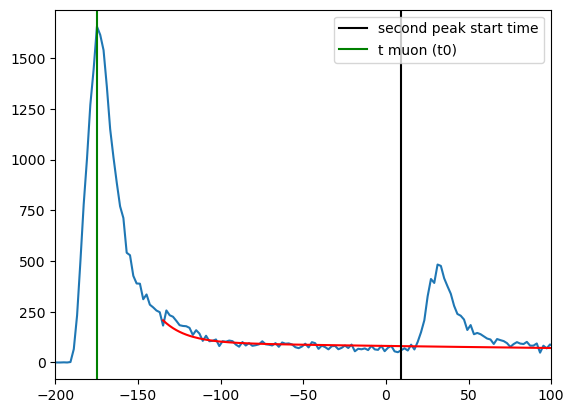

In [71]:
plt.plot(x[4500:6500], y[4500:6500])
plt.plot(x_axis,test(x_axis,param1[0],param1[1],param1[2]),'r') #plotting the test function
plt.axvline(9.25115639454998, color = 'k', label = "second peak start time") #plot the starting point for the second peak for integration
plt.axvline(-174.77184648080947, color = 'green', label = "t muon (t0)")
#plt.axhline(60.43858617544174, color = 'yellow')
plt.xlim(-200, 100)
plt.legend()
plt.show()

In [89]:
#Integrate the plot above by finding the starting point of the second peak, which is the starting point for three consecutive slopes before the second peak
#and subtracting the red exponential from the second peak for (40 and 90 ns) 2 ns equals a bin 

#Loop to find the starting point of the secondary peak
#o = np.arange(0, len(x)-1);
#for i in o:
 #   if y[i] > y[i-1] and y[i] < y[i+1] and y[i] < y2max and x[i] > 0 and x[i] < 250:
  #      print(x[i] , y[i], i)
#Based on the above code the starting point of the secondary peak should be (23.25290661332656, 208.07902646064758 )
        
#Loop to find the starting point of the primary peak (t0) which is t muon for the fitting equation below
#o = np.arange(0, len(x)-1);
#for i in o:
 #   if y[i] == np.max(y):
  #       print(x[i] , y[i], i)
#Based on the above code the starting point of the primary peak should be (-174.77184648080947, 1656.440967798233)
t0 = -174.77184648080947

#Integrate for 20 bins
bins = np.arange(23, 42)
sum = 0
for i in bins:
    #print(y[i+4983])
    sum += y[i+4983] - (apara*np.exp(-(i-t0)/tspara) + bpara*np.exp(-(i-t0)/743.))
print("Number of PEs (photoelectron):", sum)

#Integrate for 45 bins
bins2 = np.arange(23, 67)
sum2 = 0
for i in bins2:
   # print(y[i+4500])
    sum2 += y[i+4983] - (apara*np.exp(-(i-t0)/tspara) + bpara*np.exp(-(i-t0)/743.))
print("Number of PEs (photoelectron):", sum2)

Number of PEs (photoelectron): 3525.5454810550373
Number of PEs (photoelectron): 4218.541988939719


In [25]:
#Define function for fitting the muon track, where tt is undefined
def test2(t,a,b,ts,tt):
    return (np.heaviside(t-t0, 1.))*a*np.exp(-(t-t0)/ts) + (np.heaviside(t-t0,1.))*b*np.exp(-(t-t0)/tt)

In [27]:
#Design curve fit based on above function and muon data
param2, param_cov2 = curve_fit(test2, x[loc_max+1:loc2_max-15], y[loc_max+1:loc2_max-15])
print(param2)
print(param_cov2)

[1793.2194199   165.50741104   13.14540438  177.63546502]
[[ 5.56260638e+02 -1.47963924e+02 -1.20392088e+00  2.78912105e+02]
 [-1.47963924e+02  3.16928365e+02 -5.21003239e+00 -5.36840263e+02]
 [-1.20392088e+00 -5.21003239e+00  1.32556904e-01  8.28964359e+00]
 [ 2.78912105e+02 -5.36840263e+02  8.28964359e+00  1.01039148e+03]]


In [29]:
#Display parameters associated with each value for the function
print("a = ", param2[0], " +/- ", param_cov2[0][0]) 
print("b = ", param2[1], " +/- ", param_cov2[1][1])
print("ts = ", param2[2], " +/- ", param_cov2[2][2])
print("tt = ", param2[3], " +/- ", param_cov2[3][3])
apara2 = param2[0]
bpara2 = param2[1]
tspara2 = param2[2]
ttpara = param2[3]

a =  1793.2194199046373  +/-  556.2606377637026
b =  165.50741103774152  +/-  316.92836509156564
ts =  13.145404378398638  +/-  0.1325569043979827
tt =  177.6354650182899  +/-  1010.3914779652947


(-200.0, 200.0)

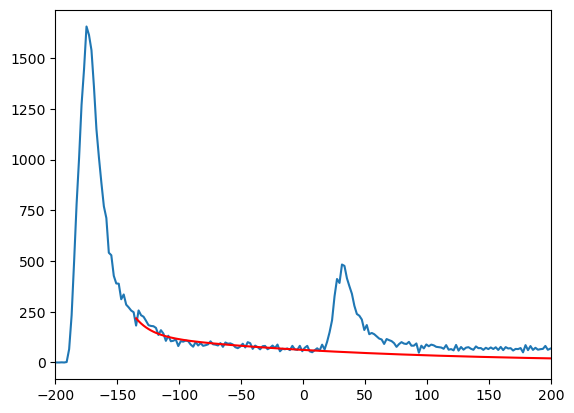

In [31]:
plt.plot(x[4500:5500], y[4500:5500])
plt.plot(x_axis, test2(x_axis,param2[0],param2[1], param2[2], param2[3]),'r') #plotting the test function
plt.xlim(-200, 200)

In [91]:
#Integrate the plot above by finding the starting point of the second peak, which is the starting point for three consecutive slopes before the second peak
#and subtracting the red exponential from the second peak for (40 and 90 ns) 2 ns equals a bin 

#Loop to find the starting point of the secondary peak
#o = np.arange(0, len(x)-1);
#for i in o:
 #   if y[i] > y[i-1] and y[i] < y[i+1] and y[i] < y2max and x[i] > 1000:
  #      print(x[i] , y[i], i)
#Based on the above code the starting point of the secondary peak should be (1337.4171771471447, 2.3070671558380127)

#Loop to find the starting point of the primary peak (t0) which is t muon for the fitting equation below
#o = np.arange(0, len(x)-1);
#for i in o:
 #   if y[i] == np.max(y):
         #print(x[i] , y[i], i)
#Based on the above code the starting point of the primary peak should be (-216.77709713714103, 956.901932477951)
#t02 = -216.77709713714103

sum3 = 0
for i in bins:
   # print(y[i+4500])
    sum3 += y[i+4983] - (apara2*np.exp(-(i-t0)/tspara2) + bpara2*np.exp(-(i-t0)/ttpara))
print("Number of PEs (photoelectron):",sum3)

sum4 = 0
for i in bins2:
    sum4 += y[i+4983] - (apara2*np.exp(-(i-t0)/tspara2) + bpara2*np.exp(-(i-t0)/ttpara))
print("Number of PEs (photoelectron):",sum4)

Number of PEs (photoelectron): 4026.988597167138
Number of PEs (photoelectron): 5473.006535410517
